# 08 — Track A: clinical and statistical reproduction from source data
Source data: MOESM3–10 (per-figure Excel files). Discovery (INSPIRE, n = 31), melanoma validation (n = 28),
NSCLC validation (n = 34). R survival + survminer, as in the paper.

## Step 14.1 — Setup and list the source data sheets

In [1]:
suppressPackageStartupMessages({
  library(tidyverse); library(readxl); library(survival); library(survminer)
})
proj <- "/mnt/d/project3_IFN-I"
sdir <- file.path(proj, "source_data")
f <- function(i) file.path(sdir, sprintf("41590_2022_1262_MOESM%d_ESM.xlsx", i))

map(3:10, ~ excel_sheets(f(.x))) |> set_names(paste0("MOESM", 3:10))

$MOESM3
[1] "Fig 1e"   "Fig 1f-g"

$MOESM4
[1] "Fig 2d" "Fig 2e" "Fig 2f"

$MOESM5
[1] "Fig 3a" "Fig 3b" "Fig 3c"

$MOESM6
[1] "Fig 4c"   "Fig 4d-e" "Fig 4f"   "Fig 4h"  

$MOESM7
[1] "Extended Data Fig 1c" "Extended Data Fig 1d"

$MOESM8
[1] "Extended Data Fig 3e"

$MOESM9
[1] "Extended Data Fig 4a" "Extended Data Fig 4b"

$MOESM10
[1] "Extended Data Fig 5a" "Extended Data Fig 5b"

## Step 14.2 — Overall survival by CD4 Teff IRC (Fig 2e–f)

dataset,irc,n
<chr>,<fct>,<int>
Discovery,low,20
Discovery,high,11
Validation (Melanoma),low,16
Validation (Melanoma),high,12
Validation (NSCLC),low,15
Validation (NSCLC),high,19


dataset,n,events,logrank_p,HR_high_vs_low,CI_low,CI_high
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Discovery,31,21,0.00241,3.60,1.49,8.69
Validation (Melanoma),28,13,0.00289,5.81,1.58,21.41
Validation (NSCLC),34,20,0.01900,3.07,1.15,8.17


Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


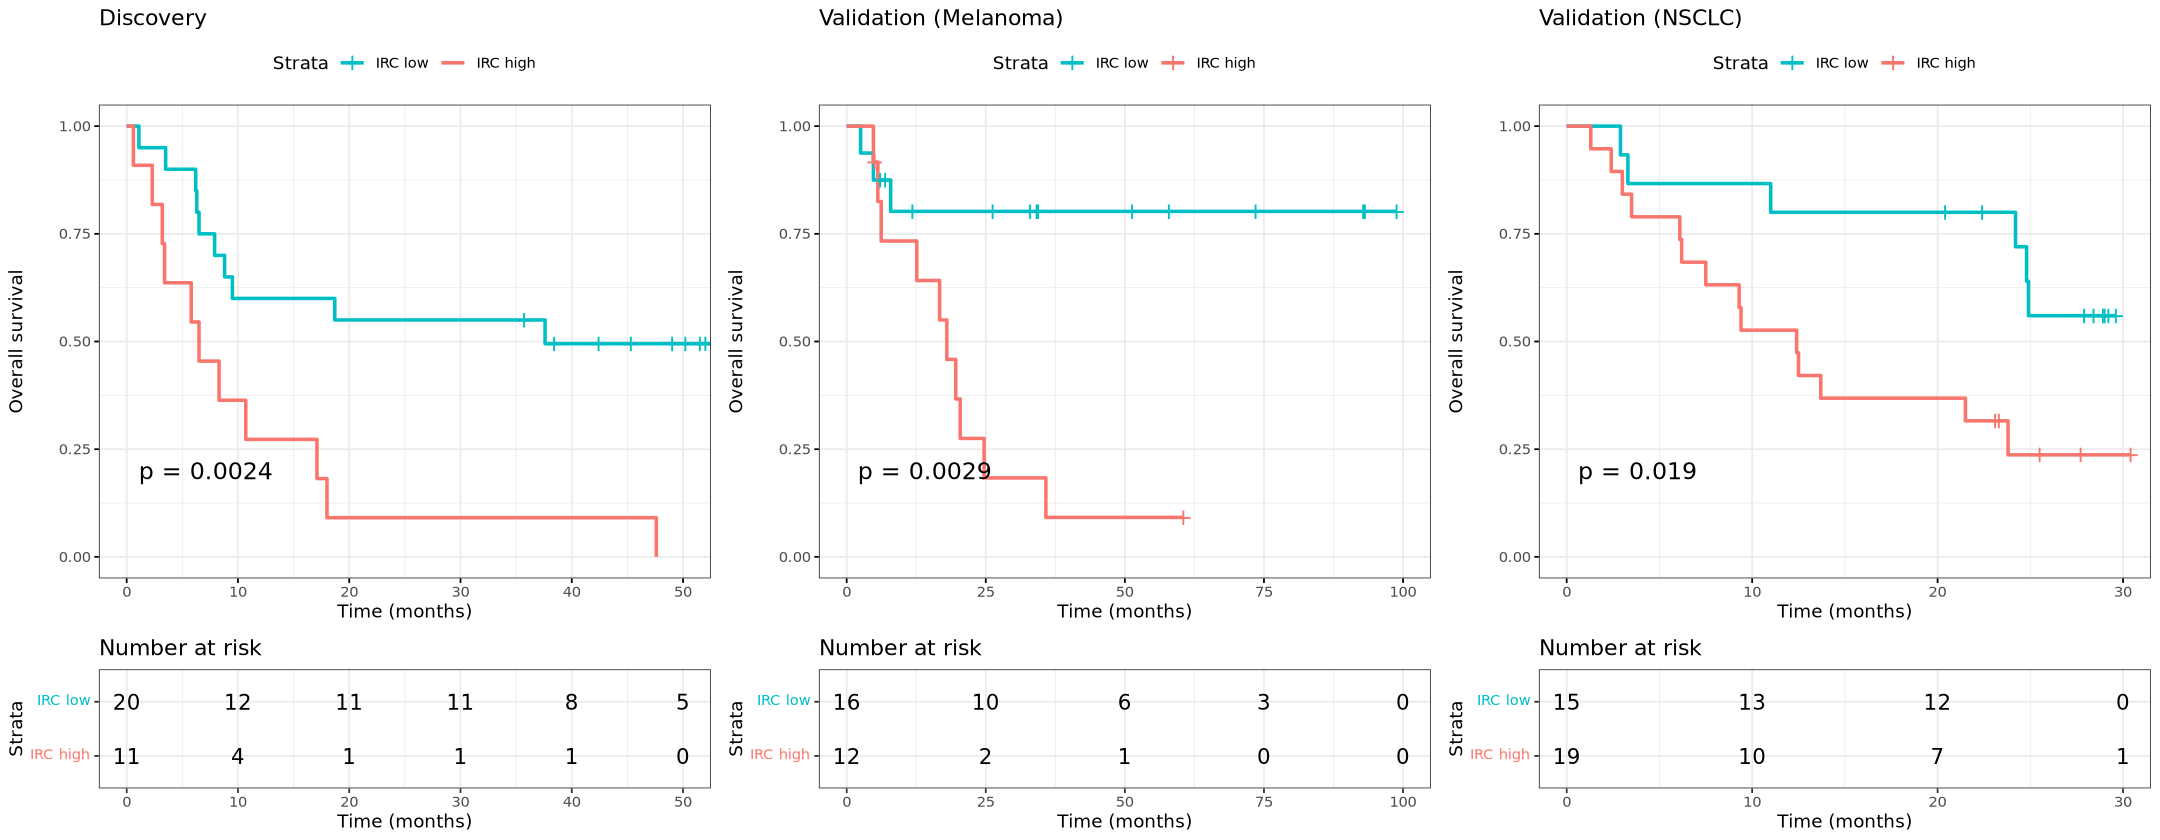

In [2]:
os <- bind_rows(read_excel(f(4), sheet = "Fig 2e"),
                read_excel(f(4), sheet = "Fig 2f")) |>
  rename(patient = `Patient (de-Identified)`, irc = `CD4eff IRC designation`,
         time = `OS (Months)`, status = OS_status, dataset = Dataset) |>
  mutate(irc = factor(irc, levels = c("low", "high")))
count(os, dataset, irc)

km_stats <- os |>
  group_by(dataset) |>
  group_modify(~ {
    lr  <- survdiff(Surv(time, status) ~ irc, data = .x)
    cox <- summary(coxph(Surv(time, status) ~ irc, data = .x))
    tibble(n = nrow(.x), events = sum(.x$status),
           logrank_p = signif(pchisq(lr$chisq, df = 1, lower.tail = FALSE), 3),
           HR_high_vs_low = round(cox$conf.int[1, "exp(coef)"], 2),
           CI_low  = round(cox$conf.int[1, "lower .95"], 2),
           CI_high = round(cox$conf.int[1, "upper .95"], 2))
  }) |> ungroup()
km_stats
write_csv(km_stats, file.path(proj, "results/tables/08_fig2ef_km_stats.csv"))

plots <- map(c("Discovery", "Validation (Melanoma)", "Validation (NSCLC)"), function(ds) {
  d <- filter(os, dataset == ds)
  ggsurvplot(survfit(Surv(time, status) ~ irc, data = d), data = d,
             pval = TRUE, risk.table = TRUE, palette = c("#00BFC4", "#F8766D"),
             legend.labs = c("IRC low", "IRC high"), title = ds,
             xlab = "Time (months)", ylab = "Overall survival", ggtheme = theme_bw())
})
options(repr.plot.width = 18, repr.plot.height = 7)
fig2ef <- arrange_ggsurvplots(plots, ncol = 3, nrow = 1, print = TRUE)
ggsave(file.path(proj, "figures/trackA/08_fig2ef_km.png"), fig2ef, width = 18, height = 7, dpi = 150)

### Fig 2e–f — OS by CD4 Teff IRC
- Group sizes match paper exactly (20/11, 16/12, 15/19).
- Log-rank P (R survdiff): 0.0024, 0.0029, 0.019 vs paper 0.0025, 0.0031, 0.019.
  Small differences likely from OS rounded to 0.1 month in source data (ties).
- Cox HR high vs low: discovery 3.60 (1.49–8.69), melanoma 5.81 (1.58–21.41), NSCLC 3.07 (1.15–8.17).
  Consistent 3–6x hazard across cohorts; wide CIs (13–21 events per cohort).
- High-IRC proportion differs: 35% / 43% / 56%. If cut-offs were optimised per cohort (surv_cutpoint),
  validation is not a test of a pre-specified threshold. Cannot check: validation IRC values not provided.

## Step 14.3 — Fig 2d and the circularity of the high/low split

In [3]:
fig2d <- read_excel(f(4), sheet = "Fig 2d") |>
  rename(patient = `Patient (de-Identified)`, cd4_grp = `CD4eff IRC designation`,
         cd8_grp = `CD8eff IRC designation`, cd4_irc = `CD4eff IRC`, cd8_irc = `CD8Eff IRC`)

tibble(cell = c("CD4 Teff", "CD8 Teff"),
       max_low  = c(max(fig2d$cd4_irc[fig2d$cd4_grp == "low"]),  max(fig2d$cd8_irc[fig2d$cd8_grp == "low"])),
       min_high = c(min(fig2d$cd4_irc[fig2d$cd4_grp == "high"]), min(fig2d$cd8_irc[fig2d$cd8_grp == "high"])),
       exact_p  = c(wilcox.test(cd4_irc ~ cd4_grp, data = fig2d, exact = TRUE)$p.value,
                    wilcox.test(cd8_irc ~ cd8_grp, data = fig2d, exact = TRUE)$p.value)) |>
  mutate(overlap = max_low >= min_high, exact_p = signif(exact_p, 3))

cell,max_low,min_high,exact_p,overlap
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
CD4 Teff,0.6599,0.6887,2.36e-08,FALSE
CD8 Teff,0.5968,0.6162,2.36e-08,FALSE


### Fig 2d — circularity
- CD4 Teff: low <= 0.660, high >= 0.689; CD8 Teff: low <= 0.597, high >= 0.616. No overlap.
- Exact Wilcoxon P = 2.36e-8 (matches paper) = minimum possible for 11 vs 20 (2 / choose(31, 11)).
- Groups defined by cutting the same variable -> P value guaranteed; not evidence of a difference.

## Step 14.4 — Cut-point search: inflation and alternatives (discovery cohort)

[1] 31

,cutpoint,statistic
,<dbl>,<dbl>
cd4_irc,0.6599,2.714459



Maximally selected LogRank statistics using condMC

data:  Surv(time, status) by cd4_irc
M = 2.7145, p-value = 0.032
sample estimates:
estimated cutpoint 
            0.6599 


approach,HR_95CI,p
<chr>,<chr>,<dbl>
"Paper: optimal cut, naive log-rank",3.60 (1.49–8.69),0.00241
"Optimal cut, corrected for search (maxstat)",—,0.03200
"Median split (pre-specified), log-rank",1.66 (0.70–3.94),0.24700
"Continuous Cox, HR per 0.1 IRC",1.40 (1.07–1.81),0.01240
"Continuous Cox, HR per 1 SD",1.79 (1.13–2.83),0.01240


      paper
median high low
  low     0  16
  high   11   4

agg_record_563f306dfe66 
                      2

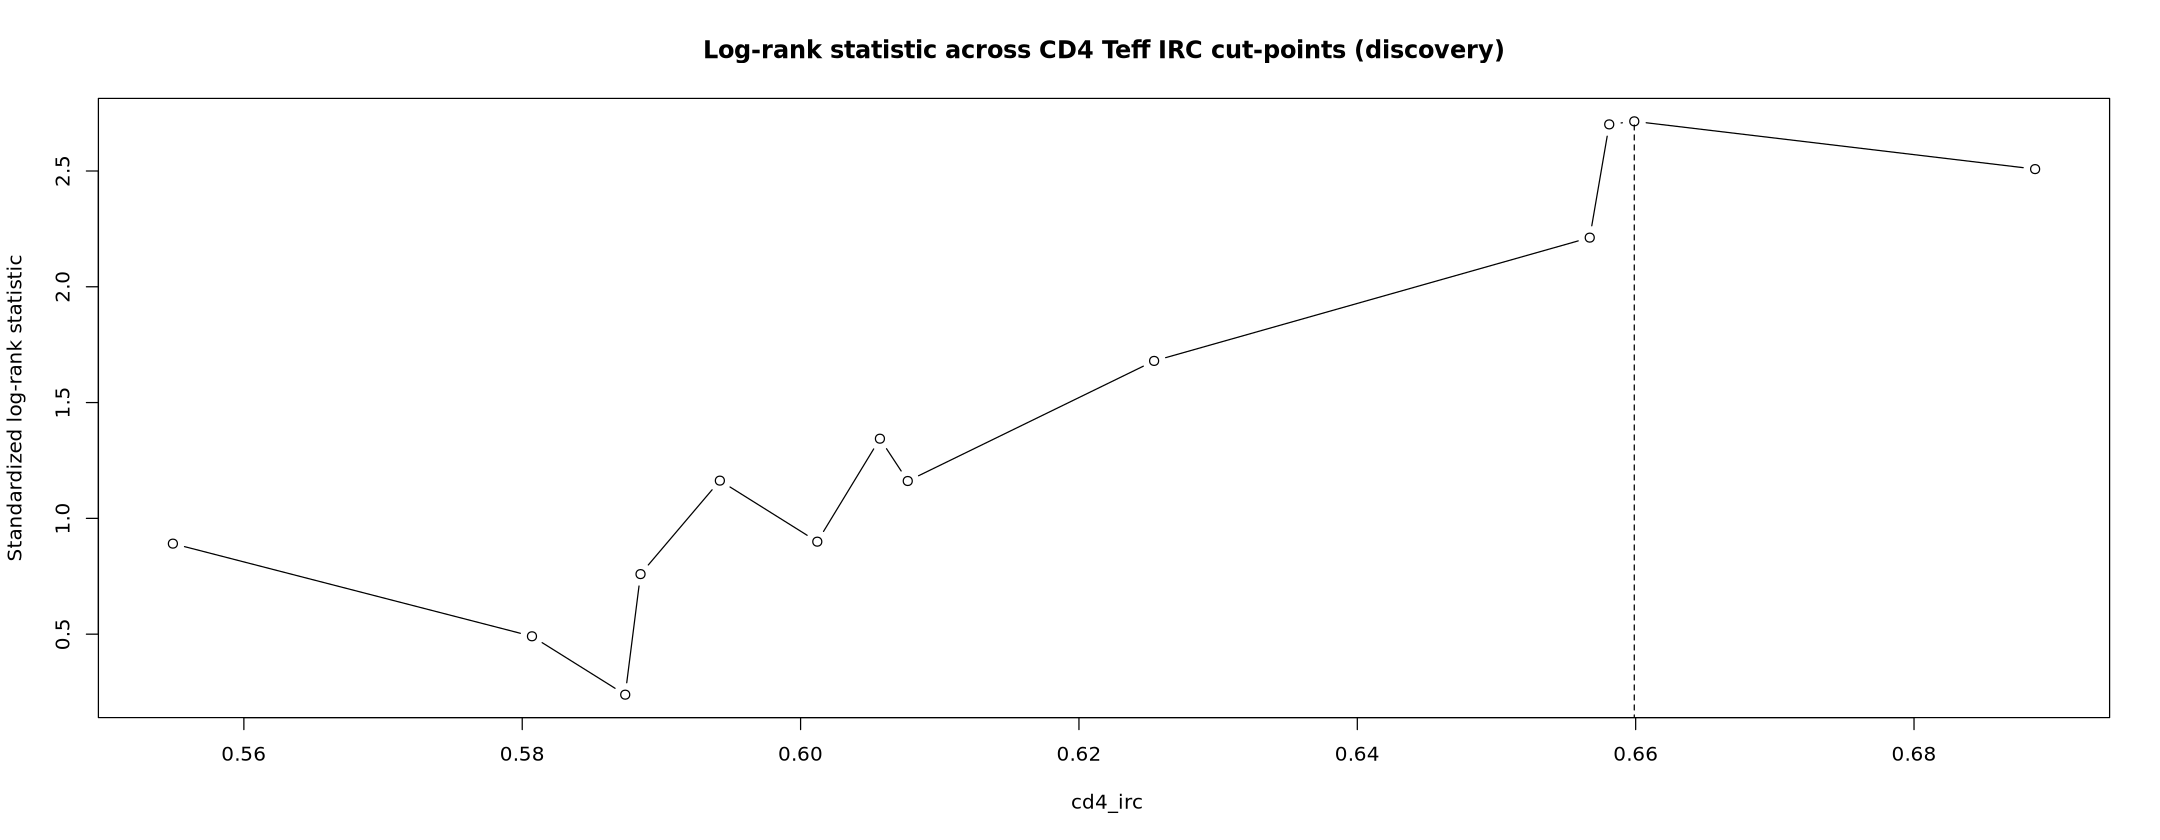

In [4]:
suppressPackageStartupMessages(library(maxstat))

disc <- fig2d |>
  dplyr::select(patient, cd4_irc, cd4_grp) |>
  inner_join(os |> filter(dataset == "Discovery") |> dplyr::select(patient, time, status), by = "patient") |>
  mutate(median_grp = factor(if_else(cd4_irc > median(cd4_irc), "high", "low"), levels = c("low", "high")))
nrow(disc)

# 1. Re-derive the optimal cut-point
cp <- surv_cutpoint(disc, time = "time", event = "status", variables = "cd4_irc", minprop = 0.3)
summary(cp)

# 2. P value corrected for searching over cut-points
set.seed(42)
ms <- maxstat.test(Surv(time, status) ~ cd4_irc, data = disc, smethod = "LogRank",
                   pmethod = "condMC", minprop = 0.3, maxprop = 0.7, B = 10000)
ms

# 3–4. Pre-specified alternatives
lr_p   <- function(g) pchisq(survdiff(Surv(time, status) ~ g, data = disc)$chisq, 1, lower.tail = FALSE)
cox_md <- summary(coxph(Surv(time, status) ~ median_grp, data = disc))
cox_c  <- summary(coxph(Surv(time, status) ~ I(cd4_irc / 0.1), data = disc))
cox_sd <- summary(coxph(Surv(time, status) ~ scale(cd4_irc), data = disc))

ci <- function(s) sprintf("%.2f (%.2f–%.2f)", s$conf.int[1, 1], s$conf.int[1, 3], s$conf.int[1, 4])
cutpoint_summary <- tibble(
  approach = c("Paper: optimal cut, naive log-rank",
               "Optimal cut, corrected for search (maxstat)",
               "Median split (pre-specified), log-rank",
               "Continuous Cox, HR per 0.1 IRC",
               "Continuous Cox, HR per 1 SD"),
  HR_95CI = c("3.60 (1.49–8.69)", "—", ci(cox_md), ci(cox_c), ci(cox_sd)),
  p = signif(c(lr_p(disc$cd4_grp), ms$p.value, lr_p(disc$median_grp),
               cox_c$coefficients[1, 5], cox_sd$coefficients[1, 5]), 3))
cutpoint_summary
table(median = disc$median_grp, paper = disc$cd4_grp)
write_csv(cutpoint_summary, file.path(proj, "results/tables/08_cutpoint_analysis.csv"))

# Log-rank statistic across all candidate cut-points
png(file.path(proj, "figures/trackA/08_maxstat_cd4.png"), width = 700, height = 450)
plot(ms, main = "Log-rank statistic across CD4 Teff IRC cut-points (discovery)")
dev.off()
plot(ms, main = "Log-rank statistic across CD4 Teff IRC cut-points (discovery)")

### Cut-point analysis (discovery, CD4 Teff IRC, n = 31)
- surv_cutpoint (minprop 0.3) re-derives cut 0.6599 = paper's 11/20 split (data-driven optimum).
- Naive log-rank P = 0.0024; maxstat corrected for search (condMC, 10,000 perms) P = 0.032 (~13x inflation).
- Median split (pre-specified): HR 1.66 (0.70–3.94), P = 0.25.
- Continuous Cox: HR 1.40 per 0.1 IRC (1.07–1.81), P = 0.012; per SD 1.79 (1.13–2.83).
- Log-rank statistic rises steadily with threshold (trend, not isolated spike); peak near upper minprop limit.
- Conclusion: association real (survives correction, significant as continuous) but effect size inflated
  by optimal cut (HR 3.60 vs ~1.7–1.8). Validation cohorts' cut-offs possibly optimised per cohort (uncheckable).

## Step 14.5 — Fig 4: suppressive ISP induction, correlations, IDO and risk-model survival

In [5]:
# --- Fig 4c: induction in high vs low CD4 Teff IRC ---
c4 <- read_excel(f(6), sheet = "Fig 4c") |>
  rename(patient = 1, grp = 2, pdl1 = 3, ido = 4, socs1 = 5, il10 = 6, dataset = 7)
fig4c <- c4 |>
  pivot_longer(c(pdl1, ido, socs1, il10), names_to = "isp", values_to = "induction") |>
  group_by(isp) |>
  summarise(high_median = median(induction[grp == "high"]),
            low_median  = median(induction[grp == "low"]),
            p = suppressWarnings(wilcox.test(induction ~ grp)$p.value), .groups = "drop") |>
  mutate(across(where(is.numeric), ~ signif(.x, 3)))
fig4c

# --- Fig 4d–e: correlations ---
de <- read_excel(f(6), sheet = "Fig 4d-e") |>
  rename(patient = 1, myeloid_irc = 2, pdl1 = 3, ido = 4, dataset = 5)
ct <- function(x, y) { t <- cor.test(x, y); c(r = unname(t$estimate), p = t$p.value) }
fig4de <- tibble(pair = c("Myeloid IRC vs PD-L1", "Myeloid IRC vs IDO", "PD-L1 vs IDO"),
                 rbind(ct(de$myeloid_irc, de$pdl1), ct(de$myeloid_irc, de$ido), ct(de$pdl1, de$ido)) |>
                   as_tibble()) |>
  mutate(r = round(r, 2), p = signif(p, 3))
fig4de

# --- Fig 4f and 4h: survival ---
km_stat <- function(d, g) {
  grp <- d[[g]]
  lr <- survdiff(Surv(d$time, d$status) ~ grp)
  cx <- summary(coxph(Surv(d$time, d$status) ~ grp))
  tibble(n = nrow(d), events = sum(d$status),
         logrank_p = signif(pchisq(lr$chisq, 1, lower.tail = FALSE), 3),
         HR = round(cx$conf.int[1, 1], 2),
         CI = sprintf("%.2f–%.2f", cx$conf.int[1, 3], cx$conf.int[1, 4]))
}

f4f <- read_excel(f(6), sheet = "Fig 4f") |>
  rename(patient = 1, time = 2, status = 3, ido_grp = 4) |>
  mutate(ido_grp = factor(ido_grp, levels = c("high", "low")))
f4h <- read_excel(f(6), sheet = "Fig 4h") |>
  rename(patient = 1, time = 2, status = 3, risk = 4) |>
  mutate(risk = factor(risk, levels = c("low risk", "high risk")),
         set  = if_else(startsWith(patient, "L"), "Test (NSCLC)", "Training (discovery + melanoma)"))

fig4fh <- bind_rows(
  "Fig 4f: IDO low vs high (all)"   = km_stat(f4f, "ido_grp"),
  "Fig 4h: high vs low risk (all)"  = km_stat(f4h, "risk"),
  "Fig 4h: training only"           = km_stat(filter(f4h, set != "Test (NSCLC)"), "risk"),
  "Fig 4h: test only (NSCLC)"       = km_stat(filter(f4h, set == "Test (NSCLC)"), "risk"),
  .id = "analysis")
fig4fh
write_csv(fig4fh, file.path(proj, "results/tables/08_fig4fh_km_stats.csv"))

# 24-month survival by risk group (Kaplan–Meier), test set and all
s24 <- function(d) {
  s <- summary(survfit(Surv(time, status) ~ risk, data = d), times = 24, extend = TRUE)
  tibble(risk = sub("risk=", "", s$strata), surv_24m = round(s$surv, 3),
         lower = round(s$lower, 3), upper = round(s$upper, 3))
}
bind_rows("All" = s24(f4h), "Test (NSCLC)" = s24(filter(f4h, set == "Test (NSCLC)")), .id = "set")

# Plots
mk <- function(d, g, labs, title) {
  ggsurvplot(survfit(as.formula(paste("Surv(time, status) ~", g)), data = d), data = d,
             pval = TRUE, risk.table = TRUE, palette = c("#00BFC4", "#F8766D"),
             legend.labs = labs, title = title, xlab = "Time (months)", ggtheme = theme_bw())
}
p4 <- list(mk(f4f, "ido_grp", c("IDO high", "IDO low"), "Fig 4f: IDO induction (all, n = 93)"),
           mk(f4h, "risk", c("Low risk", "High risk"), "Fig 4h: risk model (all, n = 93)"),
           mk(filter(f4h, set != "Test (NSCLC)"), "risk", c("Low risk", "High risk"), "Training (n = 59)"),
           mk(filter(f4h, set == "Test (NSCLC)"), "risk", c("Low risk", "High risk"), "Test: NSCLC (n = 34)"))
options(repr.plot.width = 20, repr.plot.height = 7)
fig4 <- arrange_ggsurvplots(p4, ncol = 4, nrow = 1, print = TRUE)
ggsave(file.path(proj, "figures/trackA/08_fig4fh_km.png"), fig4, width = 20, height = 7, dpi = 150)

isp,high_median,low_median,p
<chr>,<dbl>,<dbl>,<dbl>
ido,0.3490,0.3670,0.7720
il10,0.1030,0.0424,0.0366
pdl1,1.4800,1.3200,0.0139
socs1,-0.0354,-0.0111,0.5750


pair,r,p
<chr>,<dbl>,<dbl>
Myeloid IRC vs PD-L1,0.71,1.02e-15
Myeloid IRC vs IDO,0.39,8.97e-05
PD-L1 vs IDO,0.49,6.23e-07


analysis,n,events,logrank_p,HR,CI
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Fig 4f: IDO low vs high (all),93,54,5.33e-03,2.14,1.24–3.69
Fig 4h: high vs low risk (all),93,54,4.43e-05,3.11,1.76–5.50
Fig 4h: training only,59,34,6.60e-03,2.60,1.27–5.31
Fig 4h: test only (NSCLC),34,20,3.71e-04,6.58,2.04–21.23


set,risk,surv_24m,lower,upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>
All,low risk,0.712,0.595,0.852
All,high risk,0.211,0.116,0.384
Test (NSCLC),low risk,0.789,0.626,0.996
Test (NSCLC),high risk,0.000,NA,NA


ERROR: Error in eval(x): object 'g' not found


### Fig 4 — suppressive ISPs, IDO and risk model
- 4c exact: PD-L1 P = 0.0139, IL-10 P = 0.0366 (higher in high IRC); IDO, SOCS1 ns.
- 4d–e exact: myeloid IRC vs PD-L1 R = 0.71; vs IDO R = 0.39; PD-L1 vs IDO R = 0.49.
- 4f: IDO low vs high P = 0.0053, HR 2.14 (1.24–3.69) (paper 0.0054).
- 4h risk groups: all P = 4.4e-5, HR 3.11; training P = 0.0066, HR 2.60; test (NSCLC) P = 0.00037,
  HR 6.58 (2.04–21.2). Matches paper incl. Ext Data 6c/6e.
- 24-month KM survival, test set: low risk 78.9% vs high risk 0%.
- Test-set validation is the strongest evidence; caveats: n = 34, 20 events; threshold rule for test set unclear.
- Main Fig 4h pools training + test -> optimistic; test-only is the fair estimate.
- Group sizes match paper at t0 (4f 53/40; 4h 49/44; training 30/29; test 19/15).
- Test-set high-risk curve reaches 0 at ~24 months with only 4 at risk at 20 months -> 0% estimate fragile.

## Step 14.5b — Fig 4 Kaplan–Meier plots (fixed)

Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


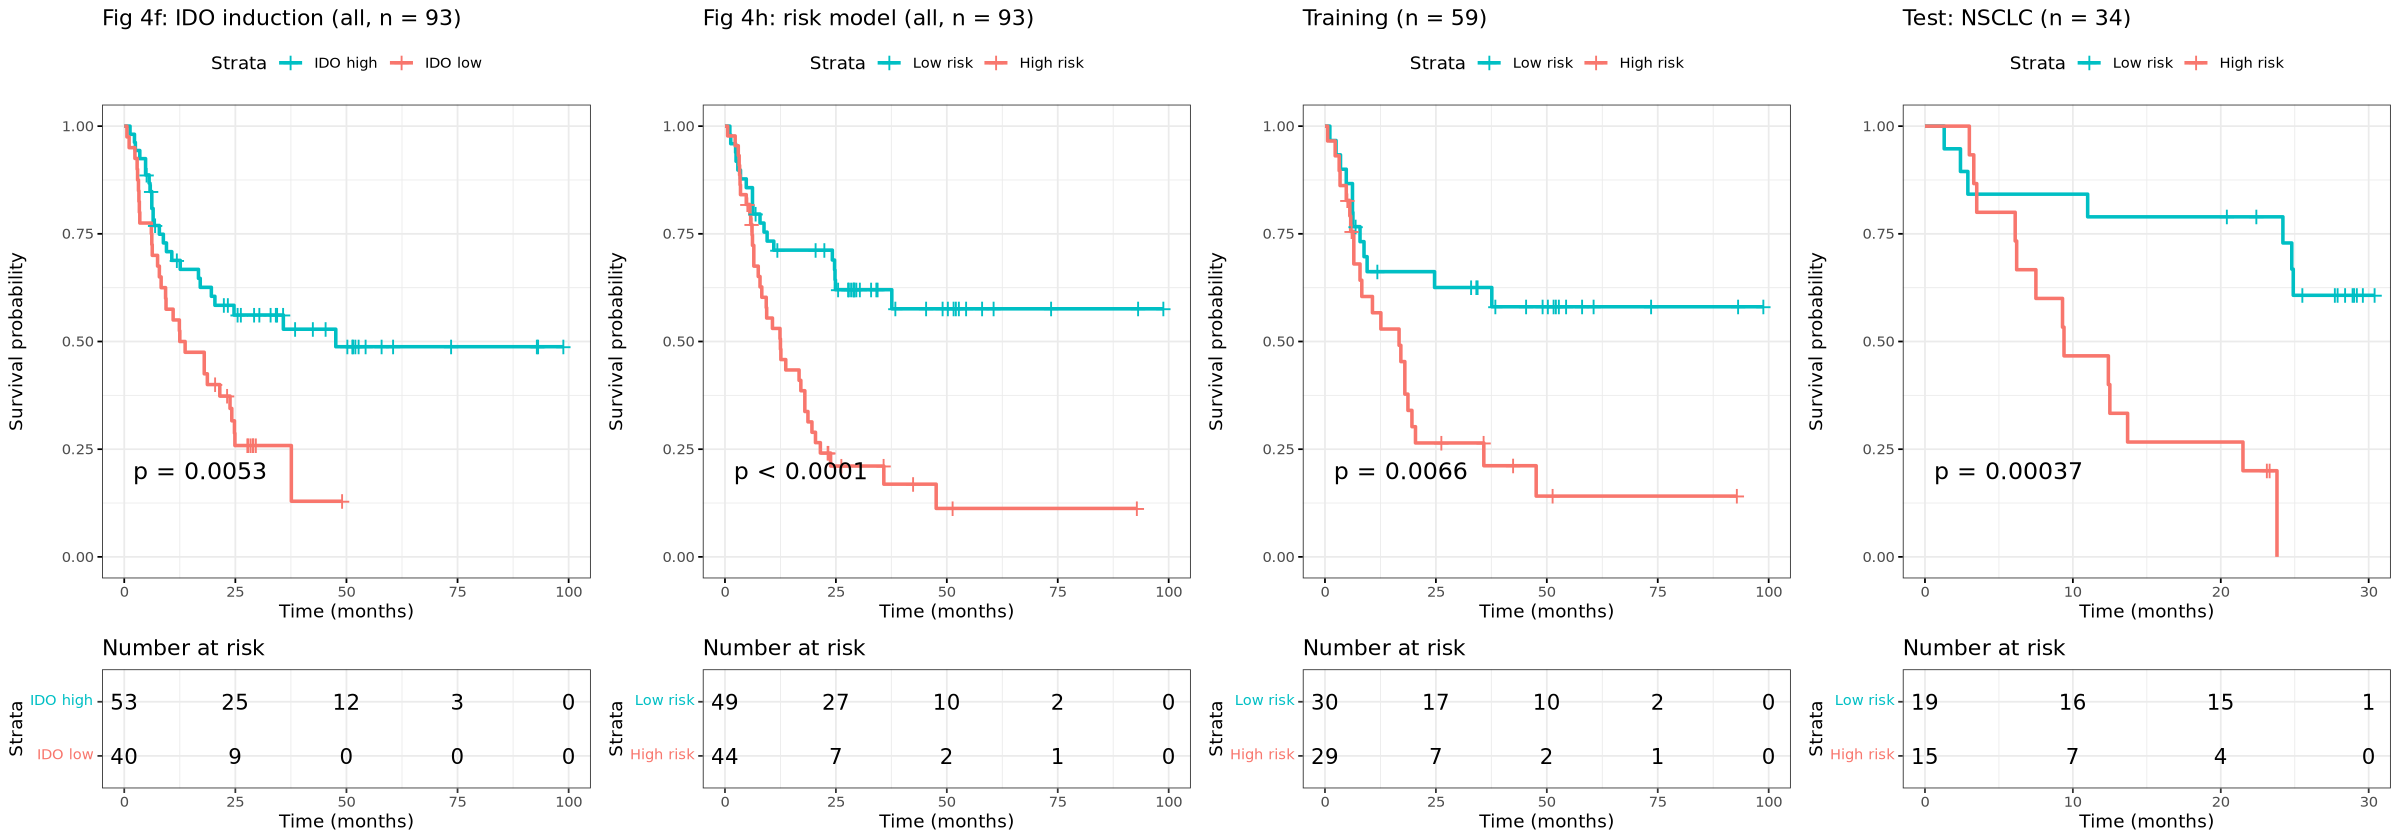

In [6]:
mk <- function(d, g, labs, title) {
  fit <- surv_fit(as.formula(paste("Surv(time, status) ~", g)), data = d)
  ggsurvplot(fit, data = d, pval = TRUE, risk.table = TRUE, palette = c("#00BFC4", "#F8766D"),
             legend.labs = labs, title = title, xlab = "Time (months)", ggtheme = theme_bw())
}

p4 <- list(mk(f4f, "ido_grp", c("IDO high", "IDO low"), "Fig 4f: IDO induction (all, n = 93)"),
           mk(f4h, "risk", c("Low risk", "High risk"), "Fig 4h: risk model (all, n = 93)"),
           mk(filter(f4h, set != "Test (NSCLC)"), "risk", c("Low risk", "High risk"), "Training (n = 59)"),
           mk(filter(f4h, set == "Test (NSCLC)"), "risk", c("Low risk", "High risk"), "Test: NSCLC (n = 34)"))
options(repr.plot.width = 20, repr.plot.height = 7)
fig4 <- arrange_ggsurvplots(p4, ncol = 4, nrow = 1, print = TRUE)
ggsave(file.path(proj, "figures/trackA/08_fig4fh_km.png"), fig4, width = 20, height = 7, dpi = 150)

## Step 14.6 — Model classification rates at 2 and 3 years (Fig 4h text)

In [7]:
yr_class <- function(d, months) {
  d2 <- d |>
    mutate(outcome = case_when(time >= months ~ "survived",
                               status == 1    ~ "died",
                               TRUE           ~ NA_character_)) |>
    filter(!is.na(outcome))
  s <- filter(d2, outcome == "survived"); dd <- filter(d2, outcome == "died")
  a <- sum(s$risk == "low risk"); b <- sum(dd$risk == "high risk")
  pa <- prop.test(a, nrow(s)); pb <- prop.test(b, nrow(dd))
  tibble(horizon = paste(months / 12, "years"), n_known = nrow(d2),
         low_risk_among_survivors = sprintf("%d/%d = %.1f%% (%.1f–%.1f)", a, nrow(s),
                                            100 * a / nrow(s), 100 * pa$conf.int[1], 100 * pa$conf.int[2]),
         high_risk_among_deaths   = sprintf("%d/%d = %.1f%% (%.1f–%.1f)", b, nrow(dd),
                                            100 * b / nrow(dd), 100 * pb$conf.int[1], 100 * pb$conf.int[2]))
}
bind_rows("All (n = 93)"    = bind_rows(yr_class(f4h, 24), yr_class(f4h, 36)),
          "Test NSCLC only" = yr_class(filter(f4h, set == "Test (NSCLC)"), 24),
          .id = "set")

set,horizon,n_known,low_risk_among_survivors,high_risk_among_deaths
<chr>,<chr>,<int>,<chr>,<chr>
All (n = 93),2 years,85,31/38 = 81.6% (65.1–91.7),33/47 = 70.2% (54.9–82.2)
All (n = 93),3 years,70,14/18 = 77.8% (51.9–92.6),34/52 = 65.4% (50.8–77.7)
Test NSCLC only,2 years,30,13/13 = 100.0% (71.7–100.0),13/17 = 76.5% (49.8–92.2)


### Fig 4h text — classification rates (pooled n = 93)
- Reproduced: 2y survivors low risk 31/38 = 81.6% (paper 81.5%); 2y deaths high risk 33/47 = 70.2%;
  3y: 14/18 = 77.8%; 34/52 = 65.4% (paper 65.3%). Wilson CIs via prop.test match paper.
- These are sensitivity-type rates (share of survivors classified low risk), not survival of low-risk
  patients (KM 24-month: low 71% vs high 21%).
- Pooled training + test -> optimistic. Test only (NSCLC): 13/13 survivors low risk; 13/17 deaths high risk
  (26/30 correct).
- "Progressing" in paper text = deaths (OS data).

## Step 14.7 — Fig 3 and Ext Data 5: paired changes, and a regression-to-the-mean check

grp,n,n_decreased,median_pre,median_post,p_paired
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
high,10,10,0.816,0.749,0.00195
low,17,5,0.587,0.636,0.03950


n,naive_r_change_vs_pre,oldham_r_change_vs_avg,oldham_p,sd_pre,sd_post
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27,-0.62,-0.11,0.572,0.18,0.162


Fig 3b TuIS high vs low: P = 0.636 
Fig 3c paired (n = 7 ): increased in 7 | P = 0.0156 
ED 5a TuIS high vs low: P = 0.697 


grp,n,n_increased,p_paired
<chr>,<int>,<int>,<dbl>
high,2,2,0.5000
low,5,5,0.0625


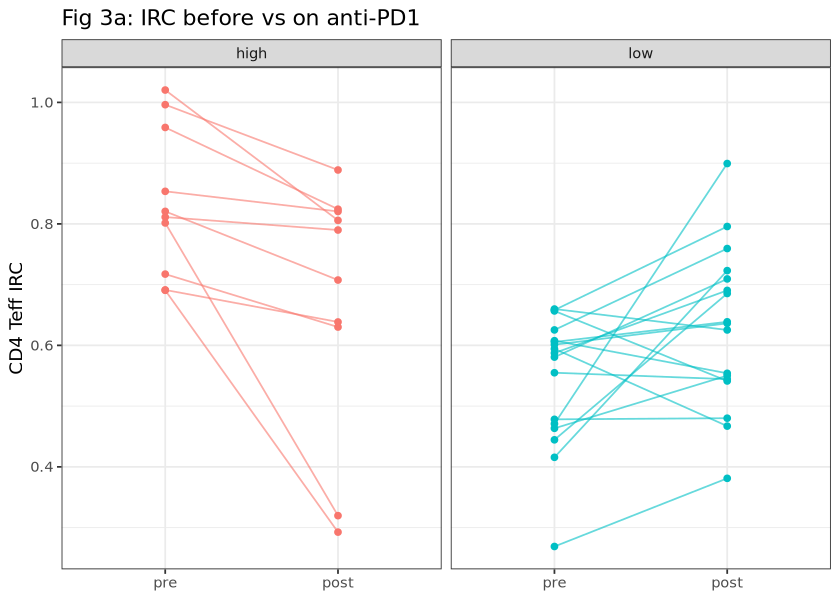

In [8]:
# --- Fig 3a: CD4 Teff IRC pre vs on treatment ---
a3 <- read_excel(f(5), sheet = "Fig 3a") |>
  rename(patient = 1, irc = 2, grp = 3, tp = 4) |>
  pivot_wider(id_cols = c(patient, grp), names_from = tp, values_from = irc) |>
  rename(pre = `Pre-Tx`, post = `On-Tx`) |>
  filter(!is.na(pre), !is.na(post))

fig3a <- a3 |>
  group_by(grp) |>
  summarise(n = n(), n_decreased = sum(post < pre),
            median_pre = round(median(pre), 3), median_post = round(median(post), 3),
            p_paired = signif(wilcox.test(post, pre, paired = TRUE, exact = TRUE)$p.value, 3),
            .groups = "drop")
fig3a

# --- Regression to the mean: Oldham's method (all patients together) ---
rtm <- a3 |> mutate(change = post - pre, avg = (post + pre) / 2)
old <- cor.test(rtm$change, rtm$avg)
tibble(n = nrow(rtm),
       naive_r_change_vs_pre = round(cor(rtm$change, rtm$pre), 2),
       oldham_r_change_vs_avg = round(unname(old$estimate), 2),
       oldham_p = signif(old$p.value, 3),
       sd_pre = round(sd(rtm$pre), 3), sd_post = round(sd(rtm$post), 3))

# --- Fig 3b: pre-therapy tumour inflammation (TuIS) by CD4 Teff IRC ---
b3 <- read_excel(f(5), sheet = "Fig 3b") |> rename(patient = 1, tp = 2, tuis = 3, grp = 4)
cat("Fig 3b TuIS high vs low: P =", signif(wilcox.test(tuis ~ grp, data = b3)$p.value, 3), "\n")

# --- Fig 3c: TuIS pre vs on treatment, low IRC ---
c3 <- read_excel(f(5), sheet = "Fig 3c") |> rename(patient = 1, tp = 2, tuis = 3, grp = 4) |>
  pivot_wider(id_cols = patient, names_from = tp, values_from = tuis)
cat("Fig 3c paired (n =", nrow(c3), "): increased in", sum(c3$`On-Tx` > c3$`Pre-Tx`), "| P =",
    signif(wilcox.test(c3$`On-Tx`, c3$`Pre-Tx`, paired = TRUE, exact = TRUE)$p.value, 3), "\n")

# --- Ext Data 5a–b: the same by CD8 Teff IRC ---
e5a <- read_excel(f(10), sheet = "Extended Data Fig 5a") |> rename(patient = 1, tp = 2, tuis = 3, grp = 4)
cat("ED 5a TuIS high vs low: P =", signif(wilcox.test(tuis ~ grp, data = e5a)$p.value, 3), "\n")
read_excel(f(10), sheet = "Extended Data Fig 5b") |>
  rename(patient = 1, tp = 2, tuis = 3, grp = 4) |>
  pivot_wider(id_cols = c(patient, grp), names_from = tp, values_from = tuis) |>
  group_by(grp) |>
  summarise(n = n(), n_increased = sum(`On-Tx` > `Pre-Tx`),
            p_paired = signif(wilcox.test(`On-Tx`, `Pre-Tx`, paired = TRUE, exact = TRUE)$p.value, 3))

# --- Plot: Fig 3a paired lines ---
options(repr.plot.width = 7, repr.plot.height = 5)
p3a <- a3 |>
  pivot_longer(c(pre, post), names_to = "tp", values_to = "irc") |>
  mutate(tp = factor(tp, levels = c("pre", "post"))) |>
  ggplot(aes(tp, irc, group = patient, colour = grp)) +
  geom_line(alpha = 0.6) + geom_point() +
  facet_wrap(~ grp) + labs(x = NULL, y = "CD4 Teff IRC", title = "Fig 3a: IRC before vs on anti-PD1") +
  theme_bw() + theme(legend.position = "none")
p3a
ggsave(file.path(proj, "figures/trackA/08_fig3a_paired.png"), p3a, width = 7, height = 5, dpi = 150)

### Fig 3 and Ext Data 5 — changes over time
- 3a reproduced: high IRC 10/10 decreased (P = 0.00195, min possible); low IRC 12/17 increased (P = 0.0395).
- Regression to the mean: naive r(change, pre) = -0.62 (biased); Oldham r(change, average) = -0.11,
  P = 0.57; SD pre 0.180 vs post 0.162 -> no convergence beyond RTM. 3a pattern fully consistent with RTM;
  paper's biological interpretation not supported over this null (limited power, n = 27).
- 3b (P = 0.64), ED 5a (P = 0.70): no TuIS difference by IRC -> reproduced.
- 3c: 7/7 low-IRC patients increased TuIS (P = 0.0156); ED 5b low CD8 IRC 5/5 (P = 0.0625).
  Both high-CD8-IRC pairs also increased -> likely general anti-PD1 effect; no proper comparison group.
- Source data mismatch: ED 5b legend high n = 4, source data only 2 pairs.

## Step 14.8 — Fig 1e: IS by cell type in HD, NCB, CB

In [9]:
f1e <- read_excel(f(3), sheet = "Fig 1e") |>
  rename(patient = 1, celltype = 2, is = 3, resp = 4) |>
  mutate(resp = recode(resp, NR = "NCB", R = "CB"))

fig1e <- f1e |>
  group_by(celltype) |>
  summarise(med_HD = median(is[resp == "HD"], na.rm = TRUE),
            med_NCB = median(is[resp == "NCB"], na.rm = TRUE),
            med_CB = median(is[resp == "CB"], na.rm = TRUE),
            p_HD_vs_NCB = wilcox.test(is[resp == "HD"], is[resp == "NCB"])$p.value,
            p_NCB_vs_CB = wilcox.test(is[resp == "NCB"], is[resp == "CB"])$p.value,
            .groups = "drop") |>
  mutate(across(where(is.numeric), ~ signif(.x, 3))) |>
  arrange(p_HD_vs_NCB)
fig1e

celltype,med_HD,med_NCB,med_CB,p_HD_vs_NCB,p_NCB_vs_CB
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B cells,0.390,0.370,0.368,0.0141,0.373
NK cells,0.424,0.338,0.333,0.0205,0.767
pDC,0.789,0.650,0.715,0.0205,0.242
DC,0.613,0.534,0.561,0.0552,0.650
CD4 T cells,0.357,0.391,0.385,0.1780,0.622
CD57+ Effector CD4 T cells,0.460,0.434,0.427,0.1980,0.622
Myeloid cells,0.597,0.533,0.544,0.2440,0.859
Effector CD8 T cells,0.418,0.417,0.421,0.4230,0.650
CD8 T cells,0.337,0.361,0.378,0.4580,0.953


### Fig 1e — IS by cell type
- Reproduced exactly: HD > NCB in B cells (P = 0.0141), NK (0.0205), pDC (0.0205); no NCB vs CB differences.
- 11 uncorrected tests, HD n = 7: after BH correction none significant (min adj P ~0.08).

## Step 14.9 — Fig 1f–g: IS "connectivity", and a permutation test

In [10]:
f1fg <- read_excel(f(3), sheet = "Fig 1f-g") |> rename(ct1 = 1, ct2 = 2, rho = 3, resp = 4, tp = 5)
pre  <- filter(f1fg, tp == "Pre")
wt   <- function(d, a, b) wilcox.test(d$rho[d$resp == a], d$rho[d$resp == b])$p.value

# 1. Paper's approach (55 correlations treated as independent)
fig1f <- tibble(comparison = c("HD vs CB", "NCB vs CB", "HD vs NCB"),
                median_rho_first = c(median(pre$rho[pre$resp == "HD"]), median(pre$rho[pre$resp == "NCB"]),
                                     median(pre$rho[pre$resp == "HD"])),
                median_rho_second = c(median(pre$rho[pre$resp == "CB"]), median(pre$rho[pre$resp == "CB"]),
                                      median(pre$rho[pre$resp == "NCB"])),
                p_wilcoxon = c(wt(pre, "HD", "CB"), wt(pre, "NCB", "CB"), wt(pre, "HD", "NCB")))
fig1f |> mutate(across(where(is.numeric), ~ signif(.x, 3)))

# Fig 1g: pre vs post within each group — unpaired (paper) and paired by cell-type pair
fig1g <- f1fg |> filter(resp != "HD") |>
  pivot_wider(id_cols = c(ct1, ct2, resp), names_from = tp, values_from = rho) |>
  group_by(resp) |>
  summarise(median_pre = median(Pre), median_post = median(Post),
            p_unpaired = wilcox.test(Pre, Post)$p.value,
            p_paired   = wilcox.test(Pre, Post, paired = TRUE)$p.value, .groups = "drop") |>
  mutate(across(where(is.numeric), ~ signif(.x, 3)))
fig1g

# 2. Recompute pre-therapy correlations from patient-level IS (Fig 1e) — sanity check
wide <- f1e |> pivot_wider(id_cols = c(patient, resp), names_from = celltype, values_from = is)
pair_rho <- function(w) { m <- cor(as.matrix(w[, -(1:2)]), method = "spearman", use = "pairwise.complete.obs")
                          m[upper.tri(m)] }
tibble(group = c("HD", "NCB", "CB"),
       median_recomputed = sapply(c("HD", "NCB", "CB"), function(g) median(pair_rho(filter(wide, resp == g)))),
       median_source     = sapply(c("HD", "NCB", "CB"), function(g) median(pre$rho[pre$resp == g]))) |>
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# 3. Permutation test: shuffle NCB/CB labels between patients (10,000 times)
pts <- filter(wide, resp %in% c("NCB", "CB"))
stat <- function(lab) median(pair_rho(pts[lab == "NCB", ])) - median(pair_rho(pts[lab == "CB", ]))
obs  <- stat(pts$resp)
set.seed(42)
perm <- replicate(10000, stat(sample(pts$resp)))
cat("Observed median rho difference (NCB - CB):", round(obs, 3),
    "| permutation P:", signif(mean(abs(perm) >= abs(obs)), 3),
    "| paper-style Wilcoxon P:", signif(wt(pre, "NCB", "CB"), 3), "\n")

comparison,median_rho_first,median_rho_second,p_wilcoxon
<chr>,<dbl>,<dbl>,<dbl>
HD vs CB,0.750,0.560,6.38e-07
NCB vs CB,0.711,0.560,1.21e-05
HD vs NCB,0.750,0.711,3.66e-01


resp,median_pre,median_post,p_unpaired,p_paired
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
CB,0.560,0.665,0.0229,0.0261
NCB,0.711,0.725,0.9330,0.6540


group,median_recomputed,median_source
<chr>,<dbl>,<dbl>
HD,0.750,0.750
NCB,0.711,0.711
CB,0.560,0.560


Observed median rho difference (NCB - CB): 0.151 | permutation P: 0.312 | paper-style Wilcoxon P: 1.21e-05 


### Fig 1f–g — IS connectivity (pairwise Spearman correlations between 11 cell types)
- Source header says "Pearson" but values are exact Spearman coefficients (n = 7, 13, 18, 15) -> header error.
- Paper-style Wilcoxon on 55 correlations: HD vs CB P = 6.4e-7, NCB vs CB P = 1.2e-5 (same values as paper,
  but brackets appear swapped in published figure; ours assign smaller P to larger median gap).
- 1g: CB pre -> post P = 0.0229 (paired 0.026); NCB ns -> reproduced.
- Recomputed correlations from Fig 1e patient data match source medians exactly (0.750, 0.711, 0.560).
- Permutation test (shuffle NCB/CB labels across 31 patients, 10,000x): median rho difference 0.151,
  P = 0.31 vs Wilcoxon 1.2e-5 -> 55 correlations are not independent; connectivity difference not supported.
- 1g likely similarly inflated (cannot test: no patient-level post-treatment IS in source data).

## Step 14.10 — Ext Data 1c–d, 3e, 4a–b

In [11]:
# --- Ext Data 1c: baseline stability ---
e1c <- read_excel(f(7), sheet = "Extended Data Fig 1c") |>
  rename(patient = 1, tp = 2, is = 3) |>
  pivot_wider(names_from = tp, values_from = is)
d  <- e1c$`Baseline 2` - e1c$`Baseline 1`; n <- length(d); se <- sd(d) / sqrt(n)
tost_p <- function(delta) max(pt((mean(d) + delta) / se, n - 1, lower.tail = FALSE),
                              pt((mean(d) - delta) / se, n - 1))
implied <- uniroot(function(x) log(tost_p(x)) - log(7.9e-48), c(0.03, 10))$root
tibble(n = n, mean_IS = round(mean(c(e1c$`Baseline 1`, e1c$`Baseline 2`)), 3),
       mean_diff = round(mean(d), 4), sd_diff = round(sd(d), 4),
       r_baselines = round(cor(e1c$`Baseline 1`, e1c$`Baseline 2`), 3),
       paired_t_p = signif(t.test(d)$p.value, 3),
       TOST_p_margin_0.02 = signif(tost_p(0.02), 3), TOST_p_margin_0.05 = signif(tost_p(0.05), 3),
       margin_implied_by_paper_P = round(implied, 3))

# --- Ext Data 1d: overall IS by response ---
e1d <- read_excel(f(7), sheet = "Extended Data Fig 1d") |> rename(patient = 1, is = 2, resp = 3)
cat("ED 1d Kruskal–Wallis HD/NCB/CB: P =", signif(kruskal.test(is ~ factor(resp), data = e1d)$p.value, 3), "\n")

# --- Ext Data 3e: IRC across 17 cell types ---
e3e <- read_excel(f(8), sheet = "Extended Data Fig 3e") |> rename(patient = 1, celltype = 2, irc = 3)
cc  <- e3e |> pivot_wider(names_from = celltype, values_from = irc) |> drop_na()
cat("ED 3e Kruskal–Wallis (paper) P =", signif(kruskal.test(irc ~ factor(celltype), data = e3e)$p.value, 3),
    "| Friedman (repeated measures, n =", nrow(cc), "complete patients) P =",
    signif(friedman.test(as.matrix(cc[, -1]))$p.value, 3), "\n")
e3e |> group_by(celltype) |> summarise(median_IRC = round(median(irc), 2), .groups = "drop") |> arrange(median_IRC)

# --- Ext Data 4a: IFNAR1 per CD4 cluster, high vs low IRC ---
e4a <- read_excel(f(9), sheet = "Extended Data Fig 4a") |> rename(patient = 1, cluster = 2, ifnar1 = 3, grp = 4)
e4a |> group_by(cluster) |>
  summarise(n_high = sum(grp == "high"), n_low = sum(grp == "low"),
            p = if (n_distinct(grp) == 2) suppressWarnings(wilcox.test(ifnar1 ~ grp)$p.value) else NA_real_,
            .groups = "drop") |>
  mutate(padj = p.adjust(p, "BH"), across(c(p, padj), ~ signif(.x, 3)))

# --- Ext Data 4b: serum IFN-gamma ---
e4b <- read_excel(f(9), sheet = "Extended Data Fig 4b") |> rename(patient = 1, ifng = 2, grp = 3)
cat("ED 4b IFN-gamma high (n =", sum(e4b$grp == "high"), ") vs low (n =", sum(e4b$grp == "low"),
    "): P =", signif(wilcox.test(ifng ~ grp, data = e4b)$p.value, 3), "\n")

n,mean_IS,mean_diff,sd_diff,r_baselines,paired_t_p,TOST_p_margin_0.02,TOST_p_margin_0.05,margin_implied_by_paper_P
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
31,0.436,0.0153,0.0294,0.891,0.00703,0.19,1.43e-07,1


ED 1d Kruskal–Wallis HD/NCB/CB: P = 0.308 
ED 3e Kruskal–Wallis (paper) P = 4.78e-48 | Friedman (repeated measures, n = 26 complete patients) P = 1.62e-50 


celltype,median_IRC
<chr>,<dbl>
Effector CD4 T cell,0.61
Effector CD8 T cell,0.73
Naive CD8 T cell,0.73
Terminal Effector CD8 T cell,0.73
Naive CD4 T cell,0.74
CD103 Myeloid cell,0.77
Foxp3 T cell,0.77
Terminal Effector CD4 T cell,0.79
Memory CD4 T cell,0.81


cluster,n_high,n_low,p,padj
<dbl>,<int>,<int>,<dbl>,<dbl>
0,11,20,0.730,0.851
1,11,20,0.583,0.816
7,11,20,0.951,0.951
8,11,20,0.244,0.788
12,11,20,0.502,0.816
20,11,20,0.338,0.788
24,11,20,NaN,NaN
30,11,20,0.183,0.788


Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”


ED 4b IFN-gamma high (n = 9 ) vs low (n = 17 ): P = 0.306 


### Ext Data 1c–d, 3e, 4a–b
- ED 1c: mean IS 0.436; baseline diff 0.015 (SD 0.029); r = 0.89; paired t P = 0.007 (small systematic drift).
  TOST equivalent at ±0.05 (P = 1.4e-7) but not ±0.02 (P = 0.19).
  Paper's P = 7.9e-48 reproduced exactly with margin ±1.0 (> 2x mean IS) -> uninformative test.
  Qualitative stability claim reasonable; reported P value meaningless.
- ED 1d: IS by response, Kruskal–Wallis P = 0.31 (no difference) -> reproduced.
- ED 3e: Kruskal–Wallis P = 4.78e-48 (exact match); Friedman (repeated measures, n = 26) P = 1.6e-50.
  Wrong test used but conclusion unaffected. Ordering reproduced (effector CD4 lowest, pDC highest).
- ED 4a: IFNAR1 no difference in any CD4 cluster (all P >= 0.18); ED 4b: IFN-gamma P = 0.31 -> reproduced.
- Bland–Altman: 95% limits of agreement ~ -0.04 to +0.07 (~±14% of mean IS); 4/31 patients outside ±0.05.
  Mean-level equivalence ≠ individual-level agreement; no test–retest data reported for IRC itself.

In [ ]:
## Step 14.11 — Figures for Fig 1e–g, permutation test, Ext Data 1c, 3e, 4b

In [12]:
dir_a <- file.path(proj, "figures/trackA")
theme_set(theme_bw())

# Fig 1e: IS by cell type and group
p1e <- f1e |>
  mutate(resp = factor(resp, levels = c("HD", "NCB", "CB"))) |>
  ggplot(aes(celltype, is, fill = resp)) +
  geom_boxplot(outlier.shape = NA) +
  geom_point(position = position_jitterdodge(jitter.width = 0.15), size = 0.6) +
  labs(x = NULL, y = "IFN-I score (IS)", fill = NULL, title = "Fig 1e: IS by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave(file.path(dir_a, "08_fig1e_is_by_celltype.png"), p1e, width = 12, height = 5, dpi = 150)

# Fig 1f–g: pairwise correlations by group and time
p1fg <- f1fg |>
  mutate(group = factor(paste(resp, tp), levels = c("HD Pre", "NCB Pre", "CB Pre", "NCB Post", "CB Post"))) |>
  ggplot(aes(group, rho, fill = resp)) +
  geom_violin(alpha = 0.6) + geom_jitter(width = 0.1, size = 0.6) +
  labs(x = NULL, y = "Spearman's rho (55 cell-type pairs)", fill = NULL, title = "Fig 1f–g: IS connectivity")
ggsave(file.path(dir_a, "08_fig1fg_connectivity.png"), p1fg, width = 8, height = 5, dpi = 150)

# Permutation null distribution vs observed difference
p_perm <- ggplot(tibble(diff = perm), aes(diff)) +
  geom_histogram(bins = 50, fill = "grey70") +
  geom_vline(xintercept = c(obs, -obs), colour = "red", linetype = c("solid", "dashed")) +
  labs(x = "Median rho difference (NCB - CB) with shuffled patient labels", y = "Permutations",
       title = sprintf("Permutation test: P = %.2f (paper-style Wilcoxon P = 1.2e-5)",
                       mean(abs(perm) >= abs(obs))))
ggsave(file.path(dir_a, "08_fig1f_permutation.png"), p_perm, width = 8, height = 5, dpi = 150)

# Ext Data 1c: Bland–Altman plot with equivalence margins
ba <- e1c |> mutate(avg = (`Baseline 1` + `Baseline 2`) / 2, diff = `Baseline 2` - `Baseline 1`)
p1c <- ggplot(ba, aes(avg, diff)) +
  geom_point() +
  geom_hline(yintercept = mean(ba$diff)) +
  geom_hline(yintercept = mean(ba$diff) + c(-1.96, 1.96) * sd(ba$diff), linetype = "dashed") +
  geom_hline(yintercept = c(-0.05, 0.05), colour = "blue", linetype = "dotted") +
  labs(x = "Mean IS of two baselines", y = "Baseline 2 - Baseline 1",
       title = "Ext Data 1c: IS agreement (dashed = 95% limits; blue = ±0.05 margin)",
       subtitle = "Paper's TOST P = 7.9e-48 corresponds to a margin of ±1.0 (off this scale)")
ggsave(file.path(dir_a, "08_extfig1c_bland_altman.png"), p1c, width = 8, height = 5, dpi = 150)

# Ext Data 3e: IRC across cell types
p3e <- e3e |>
  mutate(celltype = fct_reorder(celltype, irc, median)) |>
  ggplot(aes(irc, celltype)) +
  geom_boxplot(outlier.shape = NA) + geom_jitter(height = 0.15, size = 0.6) +
  labs(x = "IFN-I response capacity (IRC)", y = NULL, title = "Ext Data 3e: IRC by cell type")
ggsave(file.path(dir_a, "08_extfig3e_irc_by_celltype.png"), p3e, width = 7, height = 6, dpi = 150)

# Ext Data 4b: serum IFN-gamma
p4b <- ggplot(e4b, aes(grp, ifng, fill = grp)) +
  geom_boxplot(outlier.shape = NA) + geom_jitter(width = 0.1) +
  labs(x = "CD4 Teff IRC", y = "Serum IFN-gamma (pg/mL)", title = "Ext Data 4b") +
  theme(legend.position = "none")
ggsave(file.path(dir_a, "08_extfig4b_ifng.png"), p4b, width = 4, height = 5, dpi = 150)

list.files(dir_a)

[1] "08_extfig1c_bland_altman.png"    "08_extfig3e_irc_by_celltype.png"
 [3] "08_extfig4b_ifng.png"            "08_fig1e_is_by_celltype.png"    
 [5] "08_fig1f_permutation.png"        "08_fig1fg_connectivity.png"     
 [7] "08_fig2ef_km.png"                "08_fig3a_paired.png"            
 [9] "08_fig4fh_km.png"                "08_maxstat_cd4.png"

## Step 14.12 — Additional survival analyses: Ext Data 1e, 2b, 4e, 6a

In [13]:
disc_os <- os |> filter(dataset == "Discovery") |> dplyr::select(patient, time, status)

km_cox <- function(d, var, cut = NULL, minprop = 0.3) {
  d <- filter(d, !is.na(.data[[var]]))
  cut_src <- if (is.null(cut)) "optimal (surv_cutpoint)" else "paper"
  if (is.null(cut)) cut <- surv_cutpoint(d, time = "time", event = "status",
                                         variables = var, minprop = minprop)$cutpoint$cutpoint
  grp <- factor(if_else(d[[var]] > cut, "high", "low"), levels = c("low", "high"))
  lr  <- survdiff(Surv(d$time, d$status) ~ grp)
  cx  <- summary(coxph(Surv(d$time, d$status) ~ scale(d[[var]])))
  tibble(variable = var, n = nrow(d), cutoff = round(cut, 3), cut_source = cut_src,
         n_high = sum(grp == "high"), n_low = sum(grp == "low"),
         logrank_p = signif(pchisq(lr$chisq, 1, lower.tail = FALSE), 3),
         HR_per_SD = sprintf("%.2f (%.2f–%.2f)", cx$conf.int[1, 1], cx$conf.int[1, 3], cx$conf.int[1, 4]),
         cox_p = signif(cx$coefficients[1, 5], 3))
}

# Ext Data 1e: overall IS (total CD45+) — paper: P = 0.11, high 21 / low 10
ed1e <- e1d |> filter(resp != "HD") |> inner_join(disc_os, by = "patient")
res_1e <- km_cox(ed1e, "is") |> mutate(panel = "ED 1e: overall IS")

# Ext Data 2b: IS per cell subset — paper gives cut-offs for 4 subsets; claims no association
ed2b <- f1e |> filter(resp != "HD") |> dplyr::select(patient, celltype, is) |>
  inner_join(disc_os, by = "patient")
paper_cuts <- c("CD8 T cells" = 0.39, "CD4 T cells" = 0.40, "B cells" = 0.34, "Myeloid cells" = 0.53)
res_2b <- map_dfr(unique(ed2b$celltype), function(ct) {
  km_cox(filter(ed2b, celltype == ct), "is",
         cut = if (ct %in% names(paper_cuts)) paper_cuts[[ct]] else NULL) |>
    mutate(panel = paste("ED 2b:", ct))
}) |> mutate(cox_p_BH = signif(p.adjust(cox_p, "BH"), 3))

# Ext Data 4e: CD8 Teff IRC (discovery) — paper: P = 0.014, high 20 / low 11
ed4e <- fig2d |> dplyr::select(patient, cd8_irc, cd8_grp) |> inner_join(disc_os, by = "patient")
cut8 <- mean(c(max(ed4e$cd8_irc[ed4e$cd8_grp == "low"]), min(ed4e$cd8_irc[ed4e$cd8_grp == "high"])))
res_4e <- km_cox(ed4e, "cd8_irc", cut = cut8) |> mutate(panel = "ED 4e: CD8 Teff IRC")
set.seed(42)
ms8 <- maxstat.test(Surv(time, status) ~ cd8_irc, data = ed4e, smethod = "LogRank",
                    pmethod = "condMC", minprop = 0.3, maxprop = 0.7, B = 10000)
cat("ED 4e: search-corrected P (maxstat) =", signif(ms8$p.value, 3), "\n")

# Ext Data 6a: PD-L1 induction (all 93) — paper: P = 0.25. Also IDO as continuous (tests Fig 4f without a cut)
all93 <- f4h |> dplyr::select(patient, time, status) |>
  inner_join(c4 |> dplyr::select(patient, pdl1, ido), by = "patient")
res_6a <- bind_rows(km_cox(all93, "pdl1") |> mutate(panel = "ED 6a: myeloid PD-L1 induction"),
                    km_cox(all93, "ido")  |> mutate(panel = "Fig 4f check: myeloid IDO induction"))

extra_surv <- bind_rows(res_1e, res_2b, res_4e, res_6a) |> relocate(panel)
extra_surv
write_csv(extra_surv, file.path(proj, "results/tables/08_extra_survival.csv"))

ED 4e: search-corrected P (maxstat) = 0.0462 


panel,variable,n,cutoff,cut_source,n_high,n_low,logrank_p,HR_per_SD,cox_p,cox_p_BH
<chr>,<chr>,<int>,<dbl>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
ED 1e: overall IS,is,31,0.411,optimal (surv_cutpoint),21,10,0.1090,1.25 (0.80–1.95),0.3270,NA
ED 2b: B cells,is,31,0.340,paper,19,12,0.8040,0.87 (0.55–1.37),0.5360,0.926
ED 2b: CD57+ Effector CD4 T cells,is,31,0.429,optimal (surv_cutpoint),16,15,0.2380,0.92 (0.60–1.39),0.6790,0.926
ED 2b: Effector CD8 T cells,is,31,0.373,optimal (surv_cutpoint),22,9,0.1920,0.89 (0.56–1.40),0.6060,0.926
ED 2b: Foxp3 CD4 T cells,is,31,0.384,optimal (surv_cutpoint),15,16,0.5190,1.16 (0.74–1.84),0.5150,0.926
ED 2b: NK cells,is,31,0.331,optimal (surv_cutpoint),20,11,0.0771,1.06 (0.70–1.59),0.7880,0.926
ED 2b: CD4 T cells,is,31,0.400,paper,9,22,0.1040,1.15 (0.72–1.84),0.5690,0.926
ED 2b: Neutrophil,is,31,0.283,optimal (surv_cutpoint),10,21,0.1650,1.02 (0.64–1.62),0.9260,0.926
ED 2b: Myeloid cells,is,31,0.530,paper,19,12,0.4550,1.05 (0.66–1.67),0.8420,0.926


In [15]:
extra_surv |> tail(1) |> dplyr::select(panel, logrank_p, HR_per_SD, cox_p)

panel,logrank_p,HR_per_SD,cox_p
<chr>,<dbl>,<chr>,<dbl>
Fig 4f check: myeloid IDO induction,0.0368,0.85 (0.63–1.14),0.285


### Additional survival analyses (discovery OS unless stated)
- ED 1e: overall IS, optimal cut 21/10, log-rank P = 0.109 (paper 0.11); continuous HR 1.25/SD, P = 0.33 -> reproduced.
- ED 2b: no subset IS associated with OS (continuous, all P >= 0.33; BH 0.93). Paper cut-offs rounded ->
  groups differ by 1–3 patients. pDC: optimal cut P = 0.019 but continuous P = 0.35 (cut-point artefact).
- ED 4e: CD8 Teff IRC groups 20/11, log-rank P = 0.0136 (paper 0.014); search-corrected P = 0.046;
  continuous HR 1.67/SD (1.00–2.79), P = 0.049 -> borderline; weaker than CD4 (consistent with ED 6b).
- ED 6a: myeloid PD-L1 induction, optimal cut P = 0.34 (paper 0.25), continuous P = 0.66 -> no association.
  Source data give total myeloid, not CD14+ (paper) values.
- IDO (total myeloid): optimal cut P = 0.037; continuous HR 0.85/SD (0.63–1.14), P = 0.29 -> not significant
  without dichotomisation. Paper used CD14+ IDO (continuous HR 0.54, P = 0.017 in multivariable ED 6b);
  not reproducible with source data (total myeloid only) -> IDO finding cannot be independently confirmed.
  - ED 1e sensitivity: moving the single patient at the cut-off to "high" (22/9) changes P from 0.11 to 0.27
  -> data-driven splits fragile with n = 31.

## Step 14.13 — Kaplan–Meier plots for Ext Data 1e, 4e, 6a

Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


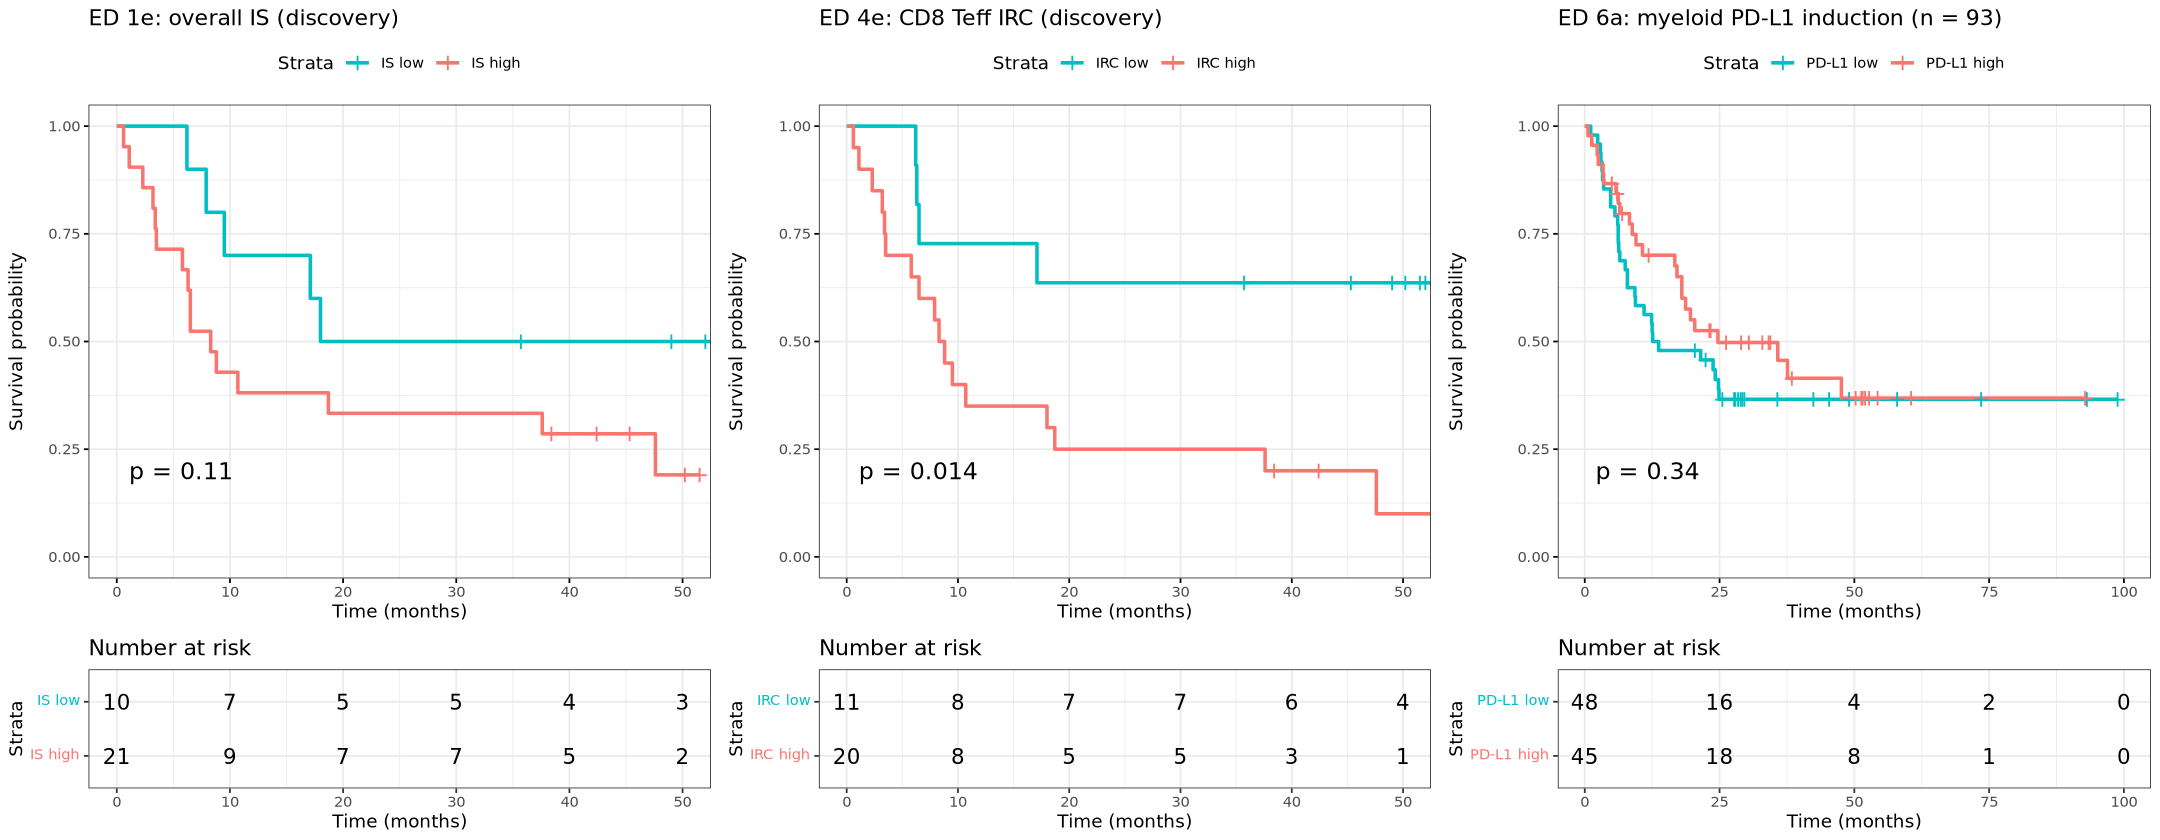

In [18]:
cut1e <- surv_cutpoint(ed1e, time = "time", event = "status", variables = "is", minprop = 0.3)$cutpoint$cutpoint
ed1e  <- ed1e |> mutate(grp = factor(if_else(is > cut1e, "high", "low"), levels = c("low", "high")))
ed4e <- ed4e  |> mutate(grp = factor(if_else(cd8_irc > cut8, "high", "low"), levels = c("low", "high")))
all93 <- all93 |> mutate(grp = factor(if_else(pdl1 > res_6a$cutoff[1], "high", "low"), levels = c("low", "high")))

pe <- list(mk(ed1e,  "grp", c("IS low", "IS high"),   "ED 1e: overall IS (discovery)"),
           mk(ed4e,  "grp", c("IRC low", "IRC high"), "ED 4e: CD8 Teff IRC (discovery)"),
           mk(all93, "grp", c("PD-L1 low", "PD-L1 high"), "ED 6a: myeloid PD-L1 induction (n = 93)"))
options(repr.plot.width = 18, repr.plot.height = 7)
fig_extra <- arrange_ggsurvplots(pe, ncol = 3, nrow = 1, print = TRUE)
ggsave(file.path(proj, "figures/trackA/08_extfig1e_4e_6a_km.png"), fig_extra, width = 18, height = 7, dpi = 150)

In [17]:
cut1e
table(ed1e$grp)

[1] 0.4110462


 low high 
  10   21 